# Lecture 9

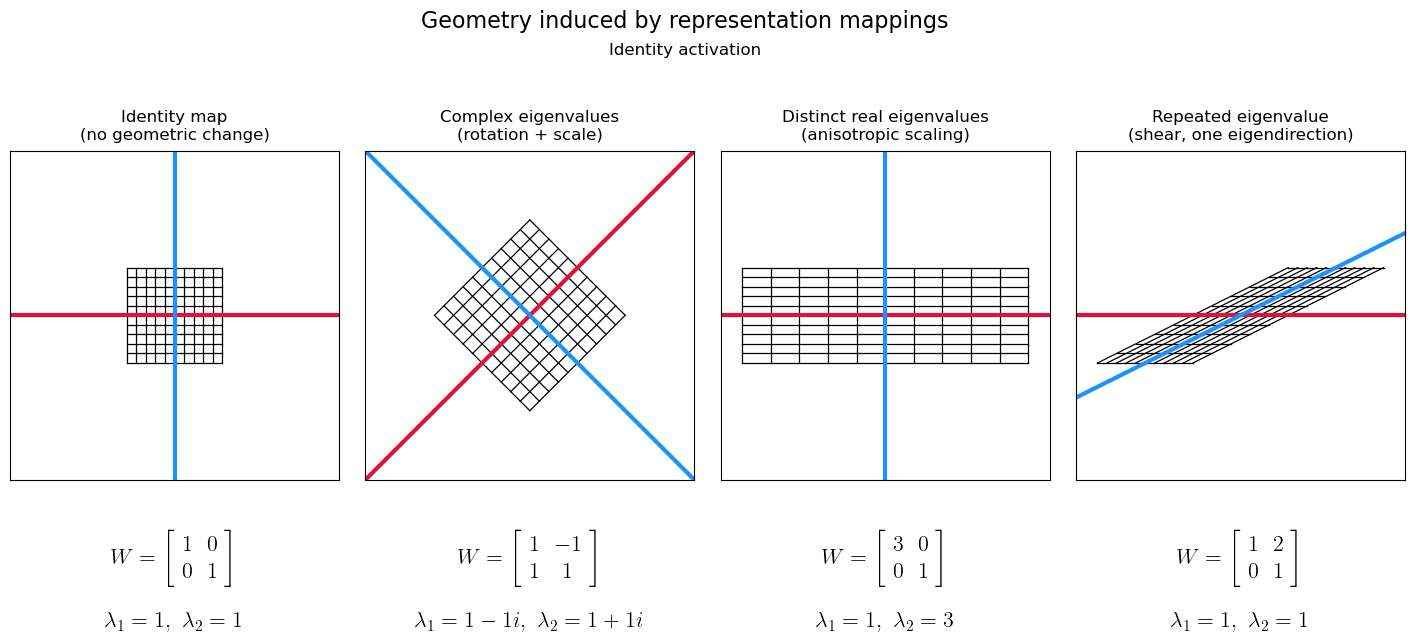

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================
# TeX ONLY for bottom row (matrices / eigenvalues)
# ============================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["pgf.texsystem"] = "pdflatex"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

# Keep Matplotlib look for plots
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 12,
})

# ============================
# Linear representation map
# ============================
def phi(W, pts_2xN):
    return W @ pts_2xN

# ============================
# Grid drawing (linear image)
# ============================
def draw_linear_grid(ax, W, grid_lim=2.5, n=11, lw=0.9):
    xs = np.linspace(-grid_lim, grid_lim, n)
    ys = np.linspace(-grid_lim, grid_lim, n)

    for x in xs:
        pts = np.stack([x*np.ones_like(ys), ys])
        img = phi(W, pts)
        ax.plot(img[0], img[1], color="black", linewidth=lw)

    for y in ys:
        pts = np.stack([xs, y*np.ones_like(xs)])
        img = phi(W, pts)
        ax.plot(img[0], img[1], color="black", linewidth=lw)

# ============================
# Image of coordinate axes
# ============================
def draw_linear_axes(ax, W, lim, lw=3.0):
    t = np.array([-lim, lim])

    e1 = W @ np.array([1.0, 0.0])
    e2 = W @ np.array([0.0, 1.0])

    ax.plot(t*e1[0], t*e1[1], color="crimson", linewidth=lw)
    ax.plot(t*e2[0], t*e2[1], color="dodgerblue", linewidth=lw)

# ============================
# Matrix + eigenvalues (TeX-safe)
# ============================
def put_matrix_block(ax, W, fontsize=16):
    ax.set_axis_off()

    a, b = int(W[0, 0]), int(W[0, 1])
    c, d = int(W[1, 0]), int(W[1, 1])

    vals = np.linalg.eigvals(W)
    vals = sorted(vals, key=lambda z: (np.real(z), np.imag(z)))

    def fmt(z, tol=1e-10):
        if abs(np.imag(z)) < tol:
            return str(int(round(np.real(z))))
        r = int(round(np.real(z)))
        i = int(round(np.imag(z)))
        sign = "+" if i >= 0 else "-"
        return rf"{r}{sign}{abs(i)}i"

    tex = (
        r"$\displaystyle "
        rf"W=\left[\begin{{array}}{{cc}} {a} & {b} \\ {c} & {d} \end{{array}}\right]"
        r"$"
        "\n\n"
        r"$\displaystyle "
        rf"\lambda_1={fmt(vals[0])},\ \lambda_2={fmt(vals[1])}"
        r"$"
    )

    ax.text(0.5, 0.55, tex, ha="center", va="center", fontsize=fontsize)

# ============================
# Matrices
# ============================
W0 = np.eye(2, dtype=int)

# Rotation by 45° + scale √2
W1 = np.array([[1, -1],
               [1,  1]], dtype=int)

# Distinct real eigenvalues
W2 = np.array([[3, 0],
               [0, 1]], dtype=int)

# Shear (defective)
W3 = np.array([[1, 2],
               [0, 1]], dtype=int)

Ws = [W0, W1, W2, W3]

titles = [
    "Identity map\n(no geometric change)",
    "Complex eigenvalues\n(rotation + scale)",
    "Distinct real eigenvalues\n(anisotropic scaling)",
    "Repeated eigenvalue\n(shear, one eigendirection)",
]

# ============================
# Common axis limits (identical scale everywhere)
# ============================
grid_lim = 2.5
corners = np.array([
    [-grid_lim, -grid_lim],
    [-grid_lim,  grid_lim],
    [ grid_lim, -grid_lim],
    [ grid_lim,  grid_lim],
]).T

def extent(W):
    return np.max(np.abs(W @ corners))

common_lim = max(extent(W) for W in Ws) * 1.15

# ============================
# Figure (2 rows)
# ============================
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 7),
    gridspec_kw={"height_ratios": [5.0, 1.0]},
)

for j, (W, title) in enumerate(zip(Ws, titles)):
    ax_top = axes[0, j]
    ax_bot = axes[1, j]

    draw_linear_grid(ax_top, W, grid_lim=grid_lim)
    draw_linear_axes(ax_top, W, lim=common_lim)

    t = ax_top.set_title(title, pad=8, fontsize=12)
    t.set_usetex(False)

    ax_top.set_aspect("equal")
    ax_top.set_xlim(-common_lim, common_lim)
    ax_top.set_ylim(-common_lim, common_lim)
    ax_top.set_xticks([])
    ax_top.set_yticks([])

    put_matrix_block(ax_bot, W, fontsize=16)

# ============================
# Global titles (Matplotlib fonts)
# ============================
st = fig.suptitle("Geometry induced by representation mappings", fontsize=16, y=0.985)
st.set_usetex(False)

sub = fig.text(0.5, 0.92, "Identity activation", ha="center", fontsize=12)
sub.set_usetex(False)

plt.subplots_adjust(top=0.82, hspace=0.18, wspace=0.08)

plt.savefig("figs/identity_geometry.pdf", bbox_inches="tight")
plt.show()

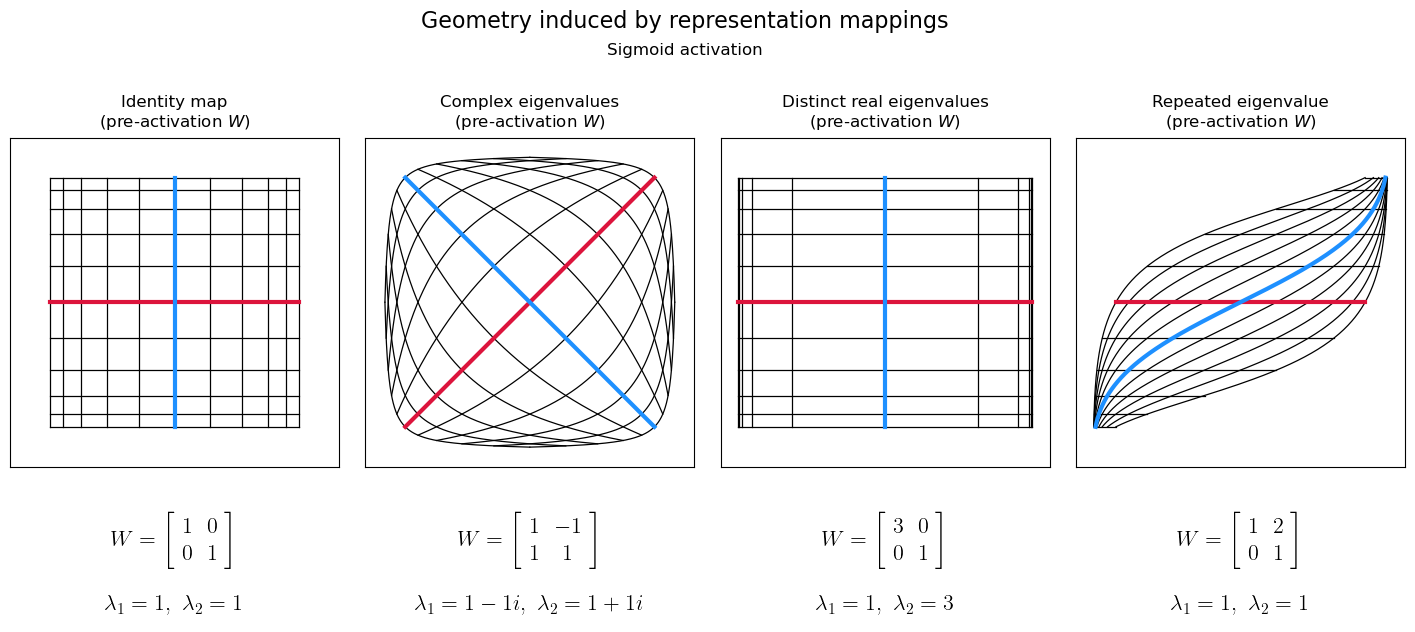

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================
# TeX ONLY so we can typeset matrices reliably,
# but we'll force titles/suptitles back to Matplotlib fonts per-text-object.
# ============================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["pgf.texsystem"] = "pdflatex"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

# Keep Matplotlib's default look for plots (titles will be forced to non-TeX below)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 12,   # smaller so panel titles don't fight suptitle
})

# ============================
# Activation + representation map
# ============================
def sigmoid(u):
    u = np.clip(u, -60, 60)
    return 1.0 / (1.0 + np.exp(-u))

def phi(W, pts_2xN):
    # representation map: x -> sigma(Wx)
    return sigmoid(W @ pts_2xN)

# ============================
# Grid drawing (nonlinear image)
# ============================
def draw_sigmoid_grid(ax, W, grid_lim=2.5, n_lines=11, n_samples=260, lw=0.9):
    xs = np.linspace(-grid_lim, grid_lim, n_lines)
    ys = np.linspace(-grid_lim, grid_lim, n_lines)
    curve = np.linspace(-grid_lim, grid_lim, n_samples)

    for x in xs:
        pts = np.stack([x*np.ones_like(curve), curve])
        img = phi(W, pts)
        ax.plot(img[0], img[1], color="black", linewidth=lw)

    for y in ys:
        pts = np.stack([curve, y*np.ones_like(curve)])
        img = phi(W, pts)
        ax.plot(img[0], img[1], color="black", linewidth=lw)

# ============================
# Image of coordinate axes (mapped through representation)
# ============================
def draw_sigmoid_axes(ax, W, grid_lim=2.5, n_samples=400, lw=3.0):
    t = np.linspace(-grid_lim, grid_lim, n_samples)

    pts_x = np.stack([t, np.zeros_like(t)])
    img_x = phi(W, pts_x)
    ax.plot(img_x[0], img_x[1], color="crimson", linewidth=lw)

    pts_y = np.stack([np.zeros_like(t), t])
    img_y = phi(W, pts_y)
    ax.plot(img_y[0], img_y[1], color="dodgerblue", linewidth=lw)

# ============================
# Matrix + eigenvalues (LaTeX-safe block)
# Use array instead of pmatrix to avoid alignment-tab (&) issues in some TeX pipelines.
# ============================
def put_matrix_block(ax, W, fontsize=16):
    ax.set_axis_off()

    a, b = int(W[0, 0]), int(W[0, 1])
    c, d = int(W[1, 0]), int(W[1, 1])

    vals = np.linalg.eigvals(W)
    vals = sorted(vals, key=lambda z: (np.real(z), np.imag(z)))

    def fmt(z):
        if abs(np.imag(z)) < 1e-10:
            return str(int(round(np.real(z))))
        r = int(round(np.real(z)))
        i = int(round(np.imag(z)))
        sign = "+" if i >= 0 else "-"
        return rf"{r}{sign}{abs(i)}i"

    tex = (
        r"$\displaystyle "
        rf"W=\left[\begin{{array}}{{cc}} {a} & {b} \\ {c} & {d} \end{{array}}\right]"
        r"$"
        "\n\n"
        r"$\displaystyle "
        rf"\lambda_1={fmt(vals[0])},\ \lambda_2={fmt(vals[1])}"
        r"$"
    )

    ax.text(0.5, 0.55, tex, ha="center", va="center", fontsize=fontsize)

# ============================
# Matrices (pre-activation linear maps)
# ============================
W0 = np.eye(2, dtype=int)

# Rotation by 45° + scale √2 (complex eigenvalues 1±i)
W1 = np.array([[1, -1],
               [1,  1]], dtype=int)

# Distinct real eigenvalues
W2 = np.array([[3, 0],
               [0, 1]], dtype=int)

# Shear (defective)
W3 = np.array([[1, 2],
               [0, 1]], dtype=int)

Ws = [W0, W1, W2, W3]

titles = [
    "Identity map\n(pre-activation $W$)",
    "Complex eigenvalues\n(pre-activation $W$)",
    "Distinct real eigenvalues\n(pre-activation $W$)",
    "Repeated eigenvalue\n(pre-activation $W$)",
]

# ============================
# Plot limits (sigmoid output lives in (0,1)^2)
# ============================
pad = 0.06
xmin, xmax = -pad, 1.0 + pad
ymin, ymax = -pad, 1.0 + pad

# ============================
# Figure (2 rows)
# ============================
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 7),
    gridspec_kw={"height_ratios": [4.6, 1.4]}
)

for j, (W, title) in enumerate(zip(Ws, titles)):
    ax_top = axes[0, j]
    ax_bot = axes[1, j]

    draw_sigmoid_grid(ax_top, W)
    draw_sigmoid_axes(ax_top, W)

    # Panel title in Matplotlib fonts (NOT TeX)
    t = ax_top.set_title(title, pad=8, fontsize=12)
    t.set_usetex(False)

    ax_top.set_aspect("equal")
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(ymin, ymax)
    ax_top.set_xticks([])
    ax_top.set_yticks([])

    put_matrix_block(ax_bot, W, fontsize=16)

# ============================
# Global titles in Matplotlib fonts (NOT TeX)
# ============================
st = fig.suptitle("Geometry induced by representation mappings", fontsize=16, y=0.985)
st.set_usetex(False)

sub = fig.text(0.5, 0.92, "Sigmoid activation", ha="center", fontsize=12)
sub.set_usetex(False)

plt.subplots_adjust(top=0.82, hspace=0.15, wspace=0.08)

plt.savefig("figs/sigmoid_geometry.pdf", bbox_inches="tight")
plt.show()


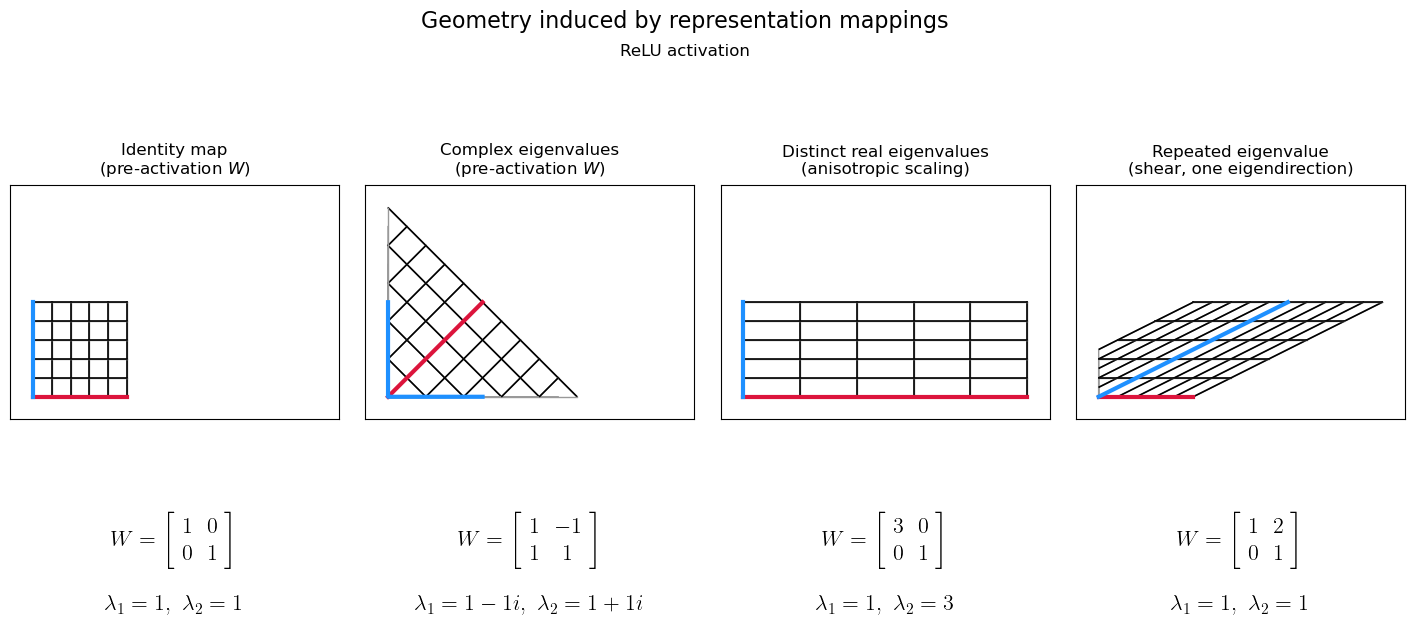

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================
# TeX ONLY so we can typeset matrices reliably,
# but we'll force titles/suptitles back to Matplotlib fonts per-text-object.
# ============================
mpl.rcParams["text.usetex"] = True
mpl.rcParams["pgf.texsystem"] = "pdflatex"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

# Keep Matplotlib's default look for plots (titles will be forced to non-TeX below)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 12,   # smaller so panel titles don't fight suptitle
})

# ============================
# Activation + representation map
# ============================
def relu(u):
    return np.maximum(u, 0.0)

def phi(W, pts_2xN):
    # representation map: x -> ReLU(Wx)
    return relu(W @ pts_2xN)

# ============================
# Grid drawing (nonlinear image)
# ============================
# def draw_relu_grid(ax, W, grid_lim=2.5, n_lines=11, n_samples=260, lw=0.9):
#     xs = np.linspace(-grid_lim, grid_lim, n_lines)
#     ys = np.linspace(-grid_lim, grid_lim, n_lines)
#     curve = np.linspace(-grid_lim, grid_lim, n_samples)

#     for x in xs:
#         pts = np.stack([x*np.ones_like(curve), curve])
#         img = phi(W, pts)
#         ax.plot(img[0], img[1], color="black", linewidth=lw)

#     for y in ys:
#         pts = np.stack([curve, y*np.ones_like(curve)])
#         img = phi(W, pts)
#         ax.plot(img[0], img[1], color="black", linewidth=lw)
def draw_relu_grid_colored(ax, W, grid_lim=2.5, n_lines=11, n_samples=400, lw=1.0):
    xs = np.linspace(-grid_lim, grid_lim, n_lines)
    ys = np.linspace(-grid_lim, grid_lim, n_lines)
    curve = np.linspace(-grid_lim, grid_lim, n_samples)

    def plot_segmented(img, u, color_active="black", color_clipped="0.6"):
        # u is pre-activation (2xN), active where both > 0
        active = (u[0] > 0) & (u[1] > 0)
        # plot in two passes: active and not-active
        ax.plot(img[0], img[1], color=color_clipped, linewidth=lw)
        ax.plot(img[0][active], img[1][active], color=color_active, linewidth=lw+0.2)

    for x in xs:
        pts = np.stack([x*np.ones_like(curve), curve])
        u = W @ pts
        img = np.maximum(u, 0.0)
        plot_segmented(img, u)

    for y in ys:
        pts = np.stack([curve, y*np.ones_like(curve)])
        u = W @ pts
        img = np.maximum(u, 0.0)
        plot_segmented(img, u)

# ============================
# Image of coordinate axes (mapped through representation)
# ============================
def draw_relu_axes(ax, W, grid_lim=2.5, n_samples=400, lw=3.0):
    t = np.linspace(-grid_lim, grid_lim, n_samples)

    pts_x = np.stack([t, np.zeros_like(t)])
    img_x = phi(W, pts_x)
    ax.plot(img_x[0], img_x[1], color="crimson", linewidth=lw)

    pts_y = np.stack([np.zeros_like(t), t])
    img_y = phi(W, pts_y)
    ax.plot(img_y[0], img_y[1], color="dodgerblue", linewidth=lw)

# ============================
# Matrix + eigenvalues (LaTeX-safe block)
# Use array instead of pmatrix to avoid alignment-tab (&) issues in some TeX pipelines.
# ============================
def put_matrix_block(ax, W, fontsize=16):
    ax.set_axis_off()

    a, b = int(W[0, 0]), int(W[0, 1])
    c, d = int(W[1, 0]), int(W[1, 1])

    vals = np.linalg.eigvals(W)
    vals = sorted(vals, key=lambda z: (np.real(z), np.imag(z)))

    def fmt(z):
        if abs(np.imag(z)) < 1e-10:
            return str(int(round(np.real(z))))
        r = int(round(np.real(z)))
        i = int(round(np.imag(z)))
        sign = "+" if i >= 0 else "-"
        return rf"{r}{sign}{abs(i)}i"

    tex = (
        r"$\displaystyle "
        rf"W=\left[\begin{{array}}{{cc}} {a} & {b} \\ {c} & {d} \end{{array}}\right]"
        r"$"
        "\n\n"
        r"$\displaystyle "
        rf"\lambda_1={fmt(vals[0])},\ \lambda_2={fmt(vals[1])}"
        r"$"
    )

    ax.text(0.5, 0.55, tex, ha="center", va="center", fontsize=fontsize)

# ============================
# Matrices (pre-activation linear maps)
# ============================
W0 = np.eye(2, dtype=int)

# Rotation by 45° + scale √2 (complex eigenvalues 1±i)
W1 = np.array([[1, -1],
               [1,  1]], dtype=int)

# Distinct real eigenvalues
W2 = np.array([[3, 0],
               [0, 1]], dtype=int)

# Shear (defective)
W3 = np.array([[1, 2],
               [0, 1]], dtype=int)

Ws = [W0, W1, W2, W3]

titles = [
    "Identity map\n(pre-activation $W$)",
    "Complex eigenvalues\n(pre-activation $W$)",
    "Distinct real eigenvalues\n(anisotropic scaling)",
    "Repeated eigenvalue\n(shear, one eigendirection)",
]

# ============================
# Plot limits (ReLU output lives in [0, +inf)^2)
# Choose limits based on imaging the input square [-grid_lim, grid_lim]^2.
# ============================
grid_lim = 2.5
corners = np.array([
    [-grid_lim, -grid_lim],
    [-grid_lim,  grid_lim],
    [ grid_lim, -grid_lim],
    [ grid_lim,  grid_lim],
]).T  # 2x4

def relu_extent(W):
    C = phi(W, corners)
    return float(np.max(C[0])), float(np.max(C[1]))

xmax = max(relu_extent(W)[0] for W in Ws)
ymax = max(relu_extent(W)[1] for W in Ws)

pad = 0.08 * max(1.0, xmax, ymax)
xmin, ymin = -pad, -pad
xmax, ymax = xmax + pad, ymax + pad

# ============================
# Figure (2 rows)
# ============================
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 7),
    gridspec_kw={"height_ratios": [4.6, 1.4]}
)

for j, (W, title) in enumerate(zip(Ws, titles)):
    ax_top = axes[0, j]
    ax_bot = axes[1, j]

    draw_relu_grid_colored(ax_top, W, grid_lim=grid_lim)
    draw_relu_axes(ax_top, W, grid_lim=grid_lim)

    # Panel title in Matplotlib fonts (NOT TeX)
    tt = ax_top.set_title(title, pad=8, fontsize=12)
    tt.set_usetex(False)

    ax_top.set_aspect("equal")
    ax_top.set_xlim(xmin, xmax)
    ax_top.set_ylim(ymin, ymax)
    ax_top.set_xticks([])
    ax_top.set_yticks([])

    put_matrix_block(ax_bot, W, fontsize=16)

# ============================
# Global titles in Matplotlib fonts (NOT TeX)
# ============================
st = fig.suptitle("Geometry induced by representation mappings", fontsize=16, y=0.985)
st.set_usetex(False)

sub = fig.text(0.5, 0.92, "ReLU activation", ha="center", fontsize=12)
sub.set_usetex(False)

plt.subplots_adjust(top=0.82, hspace=0.15, wspace=0.08)

plt.savefig("figs/relu_geometry.pdf", bbox_inches="tight")
plt.show()


In [ ]:
#!/usr/bin/env python3
"""
Circle-vs-outside toy classifier, trained with FULL-BATCH optimization,
with per-epoch visualization of input space + learned 3D representation space.

Adds: decision surface in the 3D representation panel.
  - If head == "linear": plots the exact plane logit=0.
  - If head == "mlp": samples a 3D grid in h-space and extracts the isosurface
    logit=0 via marching cubes (requires scikit-image). If not installed,
    it will print the error and fall back to plotting near-boundary points.

Key fixes so the surface looks "solid":
  - Uses *dynamic per-epoch bounds* in representation space (fits the h cloud + margin),
    preventing mesh clipping against the cube boundary.
  - Lets you crank REP_GRID_N (defaults 48) for smoother meshes.
  - Default SURF_ALPHA=1.0 (opaque).

Run:
  python circle_repr_gd_3d.py
"""

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Repro + device
# ----------------------------
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Experiment config
# ----------------------------
N = 2000
R = 1.0
BOX = 2.0
EPOCHS = 50
PLOT_EVERY = 1
OUTDIR = "figs/circle_repr3d"
os.makedirs(OUTDIR, exist_ok=True)

GRID_N = 260          # contour resolution in input space
REP_GRID_N = 48       # 3D grid resolution for marching cubes (mlp head); cost ~ O(n^3)
SURF_ALPHA = 1.0      # surface opacity in 3D panel
SURF_STRIDE = 1       # keep 1; increase to thin plotted mesh if needed
REP_MARGIN = 0.20     # expand rep bounds by this fraction beyond data extents

# Fallback if skimage missing or marching_cubes fails
NEAR_EPS = 0.02       # show points with |p-0.5| < eps
NEAR_MAX = 9000       # cap points drawn in fallback

# Model knobs
HIDDEN = 64
HEAD = "mlp"  # "linear" or "mlp"

# ----------------------------
# Data: balanced inside/outside circle
# ----------------------------
def make_circle_dataset(n=N, r=R, box=BOX):
    n_in = n // 2
    n_out = n - n_in

    # Uniform in disk
    theta = np.random.uniform(0, 2*np.pi, size=n_in).astype(np.float32)
    rad = r * np.sqrt(np.random.uniform(0, 1, size=n_in)).astype(np.float32)
    Xin = np.stack([rad*np.cos(theta), rad*np.sin(theta)], axis=1).astype(np.float32)

    # Outside via rejection sampling in square
    Xout = []
    while len(Xout) < n_out:
        cand = np.random.uniform(-box, box, size=(n_out, 2)).astype(np.float32)
        mask = np.linalg.norm(cand, axis=1) > r
        Xout.extend(cand[mask])
    Xout = np.array(Xout[:n_out], dtype=np.float32)

    y_in = np.ones(n_in, dtype=np.float32)
    y_out = np.zeros(n_out, dtype=np.float32)

    X = np.vstack([Xin, Xout]).astype(np.float32)
    y = np.concatenate([y_in, y_out]).astype(np.float32)

    idx = np.random.permutation(n)
    return X[idx], y[idx]

X_np, y_np = make_circle_dataset()
X = torch.tensor(X_np, device=device)
y = torch.tensor(y_np, device=device).view(-1, 1)

# ----------------------------
# Model: 2 -> hidden -> 3 -> head -> 1
# Keep sigmoid in the REP (as requested), but use tanh in the hidden layer.
# ----------------------------
class CircleMLP(nn.Module):
    def __init__(self, hidden=64, head="mlp"):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.fc_rep = nn.Linear(hidden, 3)

        self.act1 = nn.Tanh()
        self.act_rep = nn.ReLU()   # requested
        self.rep_bounds = (0.0, 1.0)

        self.head_type = head
        if head == "linear":
            self.head = nn.Linear(3, 1)
        elif head == "mlp":
            self.head = nn.Sequential(
                nn.Linear(3, 16),
                nn.Tanh(),
                nn.Linear(16, 1),
            )
        else:
            raise ValueError("head must be 'linear' or 'mlp'")

        # init: Xavier helps a lot here
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        z = self.act1(self.fc1(x))
        h = self.act_rep(self.fc_rep(z))   # 3D rep
        return self.head(h)

    @torch.no_grad()
    def representation(self, x):
        z = self.act1(self.fc1(x))
        h = self.act_rep(self.fc_rep(z))
        return h

    @torch.no_grad()
    def head_logits_from_h(self, h):
        """h: (...,3) in rep space -> logits (...,1)."""
        return self.head(h)

model = CircleMLP(hidden=HIDDEN, head=HEAD).to(device)

criterion = nn.BCEWithLogitsLoss(reduction="mean")

# ----------------------------
# FULL-BATCH L-BFGS
# ----------------------------
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.0015,
    max_iter=5,            # inner iterations per epoch
    history_size=50,
    line_search_fn="strong_wolfe",
)

# ----------------------------
# Plot helpers
# ----------------------------
def predict_proba_grid(model, xlim, ylim, n=GRID_N):
    xs = np.linspace(xlim[0], xlim[1], n, dtype=np.float32)
    ys = np.linspace(ylim[0], ylim[1], n, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)
    pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
    pts_t = torch.tensor(pts, device=device)
    with torch.no_grad():
        logits = model(pts_t)
        probs = torch.sigmoid(logits).view(n, n).cpu().numpy()
    return xx, yy, probs

def _plot_linear_head_plane(ax3d, head_linear: nn.Linear, bounds_lo, bounds_hi,
                           alpha=1.0, stride=1):
    """
    Plot plane w·h + b = 0 over a box defined by bounds_lo/hi (3-vectors).
    Solves for z (or y/x if needed).
    """
    w = head_linear.weight.detach().cpu().numpy().reshape(-1)  # (3,)
    b = float(head_linear.bias.detach().cpu().numpy().reshape(-1)[0])

    lo = np.array(bounds_lo, dtype=np.float32)
    hi = np.array(bounds_hi, dtype=np.float32)

    n = 60
    u = np.linspace(lo[0], hi[0], n)
    v = np.linspace(lo[1], hi[1], n)
    U, V = np.meshgrid(u, v)

    eps = 1e-8
    if abs(w[2]) > eps:
        Xs, Ys = U, V
        Zs = (-b - w[0]*Xs - w[1]*Ys) / w[2]
        mask = (Zs >= lo[2]) & (Zs <= hi[2])
        Zs = np.where(mask, Zs, np.nan)
        ax3d.plot_surface(Xs, Ys, Zs, rstride=stride, cstride=stride, alpha=alpha, linewidth=0.0)
    elif abs(w[1]) > eps:
        u = np.linspace(lo[0], hi[0], n)
        v = np.linspace(lo[2], hi[2], n)
        U, V = np.meshgrid(u, v)
        Xs, Zs = U, V
        Ys = (-b - w[0]*Xs - w[2]*Zs) / w[1]
        mask = (Ys >= lo[1]) & (Ys <= hi[1])
        Ys = np.where(mask, Ys, np.nan)
        ax3d.plot_surface(Xs, Ys, Zs, rstride=stride, cstride=stride, alpha=alpha, linewidth=0.0)
    elif abs(w[0]) > eps:
        u = np.linspace(lo[1], hi[1], n)
        v = np.linspace(lo[2], hi[2], n)
        U, V = np.meshgrid(u, v)
        Ys, Zs = U, V
        Xs = (-b - w[1]*Ys - w[2]*Zs) / w[0]
        mask = (Xs >= lo[0]) & (Xs <= hi[0])
        Xs = np.where(mask, Xs, np.nan)
        ax3d.plot_surface(Xs, Ys, Zs, rstride=stride, cstride=stride, alpha=alpha, linewidth=0.0)

def _plot_mlp_head_isosurface(ax3d, model: CircleMLP, bounds_lo, bounds_hi,
                              n=48, alpha=1.0, near_eps=0.02, near_max=9000):
    """
    For MLP head: sample logits over a 3D grid in h-space and plot the logit=0 isosurface.
    Uses marching cubes if available; otherwise prints error and falls back to near-boundary points.
    """
    lo = np.array(bounds_lo, dtype=np.float32)
    hi = np.array(bounds_hi, dtype=np.float32)

    xs = np.linspace(lo[0], hi[0], n, dtype=np.float32)
    ys = np.linspace(lo[1], hi[1], n, dtype=np.float32)
    zs = np.linspace(lo[2], hi[2], n, dtype=np.float32)

    XX, YY, ZZ = np.meshgrid(xs, ys, zs, indexing="ij")
    pts = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=1)  # (n^3,3)
    pts_t = torch.tensor(pts, device=device)

    with torch.no_grad():
        logits = model.head_logits_from_h(pts_t).view(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        logits_np = logits.view(n, n, n).cpu().numpy()

    try:
        from skimage.measure import marching_cubes

        spacing = (float(xs[1] - xs[0]), float(ys[1] - ys[0]), float(zs[1] - zs[0]))
        verts, faces, _normals, _values = marching_cubes(logits_np, level=0.0, spacing=spacing)

        # verts are in grid-origin coordinates; shift to actual lo
        verts[:, 0] += lo[0]
        verts[:, 1] += lo[1]
        verts[:, 2] += lo[2]

        ax3d.plot_trisurf(
            verts[:, 0], verts[:, 1], faces, verts[:, 2],
            alpha=0.3, linewidth=0.0, color="black"
        )
    except Exception as e:
        print("marching_cubes failed; falling back to near-boundary points. error:", repr(e))
        near = np.abs(probs - 0.5) < near_eps
        idx = np.flatnonzero(near)
        if idx.size == 0:
            return
        if idx.size > near_max:
            idx = np.random.choice(idx, size=near_max, replace=False)
        near_pts = pts[idx]
        ax3d.scatter(near_pts[:, 0], near_pts[:, 1], near_pts[:, 2], s=2, alpha=alpha)

def _dynamic_rep_bounds(h_np: np.ndarray, margin_frac: float = 0.20):
    """
    h_np: (N,3). Return (lo, hi) as 3-vectors expanded by margin_frac.
    """
    h_min = h_np.min(axis=0)
    h_max = h_np.max(axis=0)
    span = (h_max - h_min)
    span = np.maximum(span, 1e-3)  # avoid zero span
    margin = margin_frac * span
    lo = h_min - margin
    hi = h_max + margin
    return lo, hi

def plot_epoch(model, epoch, X_np, y_np, r=R, box=BOX, outdir=OUTDIR):
    inside = (y_np > 0.5)

    with torch.no_grad():
        X_t = torch.tensor(X_np, device=device)
        h = model.representation(X_t).cpu().numpy()
        logits = model(X_t).cpu().numpy().reshape(-1)
        probs = 1.0 / (1.0 + np.exp(-logits))

    # dynamic bounds to prevent surface clipping
    rep_lo, rep_hi = _dynamic_rep_bounds(h, margin_frac=REP_MARGIN)

    fig = plt.figure(figsize=(12.5, 5.4))
    ax0 = fig.add_subplot(1, 2, 1)
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")

    # --- input space
    xlim = (-box, box)
    ylim = (-box, box)
    xx, yy, pp = predict_proba_grid(model, xlim, ylim, n=GRID_N)

    ax0.scatter(X_np[~inside, 0], X_np[~inside, 1], s=10, alpha=0.7, label="class 0 (outside)")
    ax0.scatter(X_np[inside, 0], X_np[inside, 1], s=10, alpha=0.7, label="class 1 (inside)")

    t = np.linspace(0, 2*np.pi, 400)
    ax0.plot(r*np.cos(t), r*np.sin(t), linewidth=2.0, label="true boundary")
    ax0.contour(xx, yy, pp, levels=[0.5], linewidths=2.0)

    learned_proxy = plt.Line2D([0], [0], linewidth=2.0)
    handles, labels = ax0.get_legend_handles_labels()
    handles.append(learned_proxy)
    labels.append("learned boundary (p=0.5)")
    ax0.legend(handles, labels, loc="upper right", fontsize=9, frameon=True)

    ax0.set_aspect("equal")
    ax0.set_xlim(xlim)
    ax0.set_ylim(ylim)
    ax0.set_title(f"Input space (epoch {epoch})")

    # --- 3D rep space points
    # ax1.scatter(h[~inside, 0], h[~inside, 1], h[~inside, 2], s=10, alpha=0.7, label="class 0")
    # ax1.scatter(h[inside, 0], h[inside, 1], h[inside, 2], s=10, alpha=0.7, label="class 1")

    from matplotlib.colors import ListedColormap

    cmap01 = ListedColormap(["tab:blue", "tab:orange"])
    ax1.scatter(
        h[:, 0], h[:, 1], h[:, 2],
        c=inside.astype(int),
        cmap=cmap01,
        s=8,
        alpha=0.65,
        depthshade=False,   # important for ReLU pile-ups
    )

    # decision surface in rep space: logit=0 <=> p=0.5
    if model.head_type == "linear":
        _plot_linear_head_plane(
            ax1, model.head, bounds_lo=rep_lo, bounds_hi=rep_hi,
            alpha=SURF_ALPHA, stride=SURF_STRIDE
        )
    else:
        _plot_mlp_head_isosurface(
            ax1, model, bounds_lo=rep_lo, bounds_hi=rep_hi,
            n=REP_GRID_N, alpha=SURF_ALPHA,
            near_eps=NEAR_EPS, near_max=NEAR_MAX
        )

    ax1.set_xlim(rep_lo[0], rep_hi[0])
    ax1.set_ylim(rep_lo[1], rep_hi[1])
    ax1.set_zlim(rep_lo[2], rep_hi[2])

    ax1.set_xlabel("$h_1$")
    ax1.set_ylabel("$h_2$")
    ax1.set_zlabel("$h_3$")
    ax1.set_box_aspect((1, 1, 1))
    ax1.set_title(r"Representation space $h(x)\in\mathbb{R}^3$", fontsize=11)

    acc = float(((probs >= 0.5).astype(np.float32) == y_np.astype(np.float32)).mean())
    fig.suptitle(f"FULL-BATCH L-BFGS | acc={acc:.3f} | head={HEAD}", y=0.98)

    fig.tight_layout()
    outpath = os.path.join(outdir, f"epoch_{epoch:04d}.png")
    plt.savefig(outpath, dpi=160)  # no bbox_inches="tight" => consistent frame sizes
    plt.close(fig)

def make_gif(outdir=OUTDIR, gif_name="training.gif", fps=5):
    try:
        import imageio.v2 as imageio
    except Exception:
        print("imageio not installed; skipping GIF. pip install imageio")
        return

    files = sorted([f for f in os.listdir(outdir) if f.startswith("epoch_") and f.endswith(".png")])
    if not files:
        print("No frames found.")
        return

    frames = [imageio.imread(os.path.join(outdir, f)) for f in files]
    H = max(fr.shape[0] for fr in frames)
    W = max(fr.shape[1] for fr in frames)

    padded = []
    for fr in frames:
        h, w = fr.shape[:2]
        pt = (H - h) // 2
        pb = H - h - pt
        pl = (W - w) // 2
        pr = W - w - pl
        if fr.ndim == 2:
            fr2 = np.pad(fr, ((pt, pb), (pl, pr)), mode="edge")
        else:
            fr2 = np.pad(fr, ((pt, pb), (pl, pr), (0, 0)), mode="edge")
        padded.append(fr2)

    imageio.mimsave(os.path.join(outdir, gif_name), padded, fps=fps)
    print("Wrote:", os.path.join(outdir, gif_name))

# ----------------------------
# Training loop
# ----------------------------
loss_hist = []
for epoch in range(EPOCHS + 1):
    model.train()

    def closure():
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        return loss

    loss = optimizer.step(closure)
    loss_val = float(loss.detach().cpu().numpy())
    loss_hist.append(loss_val)

    if epoch % 1 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(model(X))
            preds = (probs >= 0.5).float()
            acc = float((preds == y).float().mean().cpu().numpy())
        print(f"epoch {epoch:4d} | loss {loss_val:.4f} | acc {acc:.4f}")

    if epoch % PLOT_EVERY == 0:
        plot_epoch(model, epoch, X_np, y_np)

# Loss curve
plt.figure(figsize=(6, 3.5))
plt.plot(loss_hist)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Training loss (full-batch L-BFGS)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "loss_curve.png"), dpi=160)
plt.close()

make_gif()
print("Frames in:", OUTDIR)


epoch    0 | loss 0.6905 | acc 0.6370
epoch    1 | loss 0.6543 | acc 0.6865
epoch    2 | loss 0.5938 | acc 0.7675
epoch    3 | loss 0.4539 | acc 0.8700
epoch    4 | loss 0.2969 | acc 0.9045
epoch    5 | loss 0.2586 | acc 0.9315
epoch    6 | loss 0.1973 | acc 0.9275
epoch    7 | loss 0.1839 | acc 0.9275
epoch    8 | loss 0.1735 | acc 0.9260
epoch    9 | loss 0.1637 | acc 0.9250
epoch   10 | loss 0.1577 | acc 0.9360
epoch   11 | loss 0.1409 | acc 0.9620
epoch   12 | loss 0.1079 | acc 0.9740
epoch   13 | loss 0.0918 | acc 0.9840
epoch   14 | loss 0.0736 | acc 0.9820
epoch   15 | loss 0.0626 | acc 0.9820
epoch   16 | loss 0.0603 | acc 0.9830
epoch   17 | loss 0.0523 | acc 0.9820
epoch   18 | loss 0.0489 | acc 0.9835
epoch   19 | loss 0.0446 | acc 0.9820
epoch   20 | loss 0.0414 | acc 0.9835
epoch   21 | loss 0.0396 | acc 0.9855
epoch   22 | loss 0.0356 | acc 0.9885
epoch   23 | loss 0.0273 | acc 0.9915
epoch   24 | loss 0.0228 | acc 0.9915
epoch   25 | loss 0.0208 | acc 0.9925
epoch   26 |

In [ ]:
#!/usr/bin/env python3
"""
Circle-vs-outside toy classifier, trained with FULL-BATCH optimization,
with per-epoch visualization of input space + learned 3D representation space.

Adds: decision surface in the 3D representation panel.
  - If head == "linear": plots the exact plane logit=0.
  - If head == "mlp": samples a 3D grid in h-space and extracts the isosurface
    logit=0 via marching cubes (requires scikit-image). If not installed,
    it will print the error and fall back to plotting near-boundary points.

THIS VERSION:
  - Lets you set ACT_REP at the top (identity / sigmoid / relu / tanh / softplus).
  - Saves frames and artifacts tagged with the activation:
        figs/circle_repr3d/<ACT_TAG>/epoch_<ACT_TAG>_XXXX.png
        figs/circle_repr3d/<ACT_TAG>/loss_curve_<ACT_TAG>.png
        figs/circle_repr3d/<ACT_TAG>/training_<ACT_TAG>.gif

Run:
  python circle_repr_gd_3d.py
"""

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Repro + device
# ----------------------------
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Choose representation nonlinearity
# ----------------------------
# Options: "identity", "sigmoid", "relu", "tanh", "softplus"
ACT_REP = "identity"

# used for filenames/dirs
ACT_TAG = ACT_REP.lower()

# ----------------------------
# Experiment config
# ----------------------------
N = 2000
R = 1.0
BOX = 2.0
EPOCHS = 50
PLOT_EVERY = 1

BASE_OUTDIR = "figs/circle_repr3d"
OUTDIR = os.path.join(BASE_OUTDIR, ACT_TAG)
os.makedirs(OUTDIR, exist_ok=True)

GRID_N = 260          # contour resolution in input space
REP_GRID_N = 48       # 3D grid resolution for marching cubes (mlp head); cost ~ O(n^3)
SURF_ALPHA = 1.0      # surface opacity in 3D panel
SURF_STRIDE = 1       # keep 1; increase to thin plotted mesh if needed
REP_MARGIN = 0.20     # expand rep bounds by this fraction beyond data extents

# Fallback if skimage missing or marching_cubes fails
NEAR_EPS = 0.02       # show points with |p-0.5| < eps
NEAR_MAX = 9000       # cap points drawn in fallback

# Model knobs
HIDDEN = 64
HEAD = "mlp"  # "linear" or "mlp"

# ----------------------------
# Data: balanced inside/outside circle
# ----------------------------
def make_circle_dataset(n=N, r=R, box=BOX):
    n_in = n // 2
    n_out = n - n_in

    # Uniform in disk
    theta = np.random.uniform(0, 2*np.pi, size=n_in).astype(np.float32)
    rad = r * np.sqrt(np.random.uniform(0, 1, size=n_in)).astype(np.float32)
    Xin = np.stack([rad*np.cos(theta), rad*np.sin(theta)], axis=1).astype(np.float32)

    # Outside via rejection sampling in square
    Xout = []
    while len(Xout) < n_out:
        cand = np.random.uniform(-box, box, size=(n_out, 2)).astype(np.float32)
        mask = np.linalg.norm(cand, axis=1) > r
        Xout.extend(cand[mask])
    Xout = np.array(Xout[:n_out], dtype=np.float32)

    y_in = np.ones(n_in, dtype=np.float32)
    y_out = np.zeros(n_out, dtype=np.float32)

    X = np.vstack([Xin, Xout]).astype(np.float32)
    y = np.concatenate([y_in, y_out]).astype(np.float32)

    idx = np.random.permutation(n)
    return X[idx], y[idx]

X_np, y_np = make_circle_dataset()
X = torch.tensor(X_np, device=device)
y = torch.tensor(y_np, device=device).view(-1, 1)

# ----------------------------
# Model: 2 -> hidden -> 3 -> head -> 1
# ----------------------------
def make_rep_activation(name: str) -> nn.Module:
    name = name.lower().strip()
    if name == "identity":
        return nn.Identity()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "softplus":
        return nn.Softplus(beta=1.0)
    raise ValueError(f"Unknown ACT_REP={name!r}. Use: identity, sigmoid, relu, tanh, softplus")

class CircleMLP(nn.Module):
    def __init__(self, hidden=64, head="mlp", act_rep: str = "sigmoid"):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.fc_rep = nn.Linear(hidden, 3)

        self.act1 = nn.Tanh()
        self.act_rep_name = act_rep.lower().strip()
        self.act_rep = make_rep_activation(act_rep)

        self.head_type = head
        if head == "linear":
            self.head = nn.Linear(3, 1)
        elif head == "mlp":
            self.head = nn.Sequential(
                nn.Linear(3, 16),
                nn.Tanh(),
                nn.Linear(16, 1),
            )
        else:
            raise ValueError("head must be 'linear' or 'mlp'")

        # init: Xavier helps a lot here
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        z = self.act1(self.fc1(x))
        h = self.act_rep(self.fc_rep(z))   # 3D rep
        return self.head(h)

    @torch.no_grad()
    def representation(self, x):
        z = self.act1(self.fc1(x))
        h = self.act_rep(self.fc_rep(z))
        return h

    @torch.no_grad()
    def head_logits_from_h(self, h):
        """h: (...,3) in rep space -> logits (...,1)."""
        return self.head(h)

model = CircleMLP(hidden=HIDDEN, head=HEAD, act_rep=ACT_REP).to(device)

criterion = nn.BCEWithLogitsLoss(reduction="mean")

# ----------------------------
# FULL-BATCH L-BFGS
# ----------------------------
optimizer = torch.optim.LBFGS(
    model.parameters(),
    lr=0.0015,
    max_iter=5,            # inner iterations per epoch
    history_size=50,
    line_search_fn="strong_wolfe",
)

# ----------------------------
# Plot helpers
# ----------------------------
def predict_proba_grid(model, xlim, ylim, n=GRID_N):
    xs = np.linspace(xlim[0], xlim[1], n, dtype=np.float32)
    ys = np.linspace(ylim[0], ylim[1], n, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)
    pts = np.stack([xx.ravel(), yy.ravel()], axis=1)
    pts_t = torch.tensor(pts, device=device)
    with torch.no_grad():
        logits = model(pts_t)
        probs = torch.sigmoid(logits).view(n, n).cpu().numpy()
    return xx, yy, probs

def _plot_linear_head_plane(ax3d, head_linear: nn.Linear, bounds_lo, bounds_hi,
                           alpha=1.0, stride=1):
    """
    Plot plane w·h + b = 0 over a box defined by bounds_lo/hi (3-vectors).
    Solves for z (or y/x if needed).
    """
    w = head_linear.weight.detach().cpu().numpy().reshape(-1)  # (3,)
    b = float(head_linear.bias.detach().cpu().numpy().reshape(-1)[0])

    lo = np.array(bounds_lo, dtype=np.float32)
    hi = np.array(bounds_hi, dtype=np.float32)

    n = 60
    u = np.linspace(lo[0], hi[0], n)
    v = np.linspace(lo[1], hi[1], n)
    U, V = np.meshgrid(u, v)

    eps = 1e-8
    if abs(w[2]) > eps:
        Xs, Ys = U, V
        Zs = (-b - w[0]*Xs - w[1]*Ys) / w[2]
        mask = (Zs >= lo[2]) & (Zs <= hi[2])
        Zs = np.where(mask, Zs, np.nan)
        ax3d.plot_surface(Xs, Ys, Zs, rstride=stride, cstride=stride, alpha=alpha, linewidth=0.0)
    elif abs(w[1]) > eps:
        u = np.linspace(lo[0], hi[0], n)
        v = np.linspace(lo[2], hi[2], n)
        U, V = np.meshgrid(u, v)
        Xs, Zs = U, V
        Ys = (-b - w[0]*Xs - w[2]*Zs) / w[1]
        mask = (Ys >= lo[1]) & (Ys <= hi[1])
        Ys = np.where(mask, Ys, np.nan)
        ax3d.plot_surface(Xs, Ys, Zs, rstride=stride, cstride=stride, alpha=alpha, linewidth=0.0)
    elif abs(w[0]) > eps:
        u = np.linspace(lo[1], hi[1], n)
        v = np.linspace(lo[2], hi[2], n)
        U, V = np.meshgrid(u, v)
        Ys, Zs = U, V
        Xs = (-b - w[1]*Ys - w[2]*Zs) / w[0]
        mask = (Xs >= lo[0]) & (Xs <= hi[0])
        Xs = np.where(mask, Xs, np.nan)
        ax3d.plot_surface(Xs, Ys, Zs, rstride=stride, cstride=stride, alpha=alpha, linewidth=0.0)

def _plot_mlp_head_isosurface(ax3d, model: CircleMLP, bounds_lo, bounds_hi,
                              n=48, alpha=1.0, near_eps=0.02, near_max=9000):
    """
    For MLP head: sample logits over a 3D grid in h-space and plot the logit=0 isosurface.
    Uses marching cubes if available; otherwise prints error and falls back to near-boundary points.
    """
    lo = np.array(bounds_lo, dtype=np.float32)
    hi = np.array(bounds_hi, dtype=np.float32)

    xs = np.linspace(lo[0], hi[0], n, dtype=np.float32)
    ys = np.linspace(lo[1], hi[1], n, dtype=np.float32)
    zs = np.linspace(lo[2], hi[2], n, dtype=np.float32)

    XX, YY, ZZ = np.meshgrid(xs, ys, zs, indexing="ij")
    pts = np.stack([XX.ravel(), YY.ravel(), ZZ.ravel()], axis=1)  # (n^3,3)
    pts_t = torch.tensor(pts, device=device)

    with torch.no_grad():
        logits = model.head_logits_from_h(pts_t).view(-1)
        probs = torch.sigmoid(logits).cpu().numpy()
        logits_np = logits.view(n, n, n).cpu().numpy()

    try:
        from skimage.measure import marching_cubes

        spacing = (float(xs[1] - xs[0]), float(ys[1] - ys[0]), float(zs[1] - zs[0]))
        verts, faces, _normals, _values = marching_cubes(logits_np, level=0.0, spacing=spacing)

        # verts are in grid-origin coordinates; shift to actual lo
        verts[:, 0] += lo[0]
        verts[:, 1] += lo[1]
        verts[:, 2] += lo[2]

        ax3d.plot_trisurf(
            verts[:, 0], verts[:, 1], faces, verts[:, 2],
            alpha=0.3, linewidth=0.1, edgecolor="black", color="black"
        )
    except Exception as e:
        print("marching_cubes failed; falling back to near-boundary points. error:", repr(e))
        near = np.abs(probs - 0.5) < near_eps
        idx = np.flatnonzero(near)
        if idx.size == 0:
            return
        if idx.size > near_max:
            idx = np.random.choice(idx, size=near_max, replace=False)
        near_pts = pts[idx]
        ax3d.scatter(near_pts[:, 0], near_pts[:, 1], near_pts[:, 2], s=2, alpha=alpha)

def _dynamic_rep_bounds(h_np: np.ndarray, margin_frac: float = 0.20):
    """
    h_np: (N,3). Return (lo, hi) as 3-vectors expanded by margin_frac.
    """
    h_min = h_np.min(axis=0)
    h_max = h_np.max(axis=0)
    span = (h_max - h_min)
    span = np.maximum(span, 1e-3)  # avoid zero span
    margin = margin_frac * span
    lo = h_min - margin
    hi = h_max + margin
    return lo, hi

def plot_epoch(model, epoch, X_np, y_np, r=R, box=BOX, outdir=OUTDIR, tag=ACT_TAG):
    inside = (y_np > 0.5)

    with torch.no_grad():
        X_t = torch.tensor(X_np, device=device)
        h = model.representation(X_t).cpu().numpy()
        logits = model(X_t).cpu().numpy().reshape(-1)
        probs = 1.0 / (1.0 + np.exp(-logits))

    # dynamic bounds to prevent surface clipping
    rep_lo, rep_hi = _dynamic_rep_bounds(h, margin_frac=REP_MARGIN)

    fig = plt.figure(figsize=(12.5, 5.4))
    ax0 = fig.add_subplot(1, 2, 1)
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")

    # --- input space
    xlim = (-box, box)
    ylim = (-box, box)
    xx, yy, pp = predict_proba_grid(model, xlim, ylim, n=GRID_N)

    ax0.scatter(X_np[~inside, 0], X_np[~inside, 1], s=10, alpha=0.7, label="class 0 (outside)")
    ax0.scatter(X_np[inside, 0], X_np[inside, 1], s=10, alpha=0.7, label="class 1 (inside)")

    t = np.linspace(0, 2*np.pi, 400)
    ax0.plot(r*np.cos(t), r*np.sin(t), linewidth=2.0, label="true boundary")
    ax0.contour(xx, yy, pp, levels=[0.5], linewidths=2.0)

    learned_proxy = plt.Line2D([0], [0], linewidth=2.0)
    handles, labels = ax0.get_legend_handles_labels()
    handles.append(learned_proxy)
    labels.append("learned boundary (p=0.5)")
    ax0.legend(handles, labels, loc="upper right", fontsize=9, frameon=True)

    ax0.set_aspect("equal")
    ax0.set_xlim(xlim)
    ax0.set_ylim(ylim)
    ax0.set_title(f"Input space (epoch {epoch}) | rep={tag}")

    # --- 3D rep space points
    from matplotlib.colors import ListedColormap
    cmap01 = ListedColormap(["tab:blue", "tab:orange"])
    ax1.scatter(
        h[:, 0], h[:, 1], h[:, 2],
        c=inside.astype(int),
        cmap=cmap01,
        s=8,
        alpha=0.65,
        depthshade=False,
    )

    # decision surface in rep space: logit=0 <=> p=0.5
    if model.head_type == "linear":
        _plot_linear_head_plane(
            ax1, model.head, bounds_lo=rep_lo, bounds_hi=rep_hi,
            alpha=SURF_ALPHA, stride=SURF_STRIDE
        )
    else:
        _plot_mlp_head_isosurface(
            ax1, model, bounds_lo=rep_lo, bounds_hi=rep_hi,
            n=REP_GRID_N, alpha=SURF_ALPHA,
            near_eps=NEAR_EPS, near_max=NEAR_MAX
        )

    ax1.set_xlim(rep_lo[0], rep_hi[0])
    ax1.set_ylim(rep_lo[1], rep_hi[1])
    ax1.set_zlim(rep_lo[2], rep_hi[2])

    ax1.set_xlabel("$h_1$")
    ax1.set_ylabel("$h_2$")
    ax1.set_zlabel("$h_3$")
    ax1.set_box_aspect((1, 1, 1))
    ax1.set_title(rf"Representation space $h(x)\in\mathbb{{R}}^3$ | rep={tag}", fontsize=11)

    acc = float(((probs >= 0.5).astype(np.float32) == y_np.astype(np.float32)).mean())
    fig.suptitle(f"FULL-BATCH L-BFGS | acc={acc:.3f} | head={HEAD} | rep={tag}", y=0.98)

    fig.tight_layout()
    outpath = os.path.join(outdir, f"epoch_{tag}_{epoch:04d}.png")
    plt.savefig(outpath, dpi=160)
    plt.close(fig)

def make_gif(outdir=OUTDIR, gif_name=None, fps=5):
    if gif_name is None:
        gif_name = f"training_{ACT_TAG}.gif"
    try:
        import imageio.v2 as imageio
    except Exception:
        print("imageio not installed; skipping GIF. pip install imageio")
        return

    files = sorted([f for f in os.listdir(outdir) if f.startswith(f"epoch_{ACT_TAG}_") and f.endswith(".png")])
    if not files:
        print("No frames found.")
        return

    frames = [imageio.imread(os.path.join(outdir, f)) for f in files]
    H = max(fr.shape[0] for fr in frames)
    W = max(fr.shape[1] for fr in frames)

    padded = []
    for fr in frames:
        h, w = fr.shape[:2]
        pt = (H - h) // 2
        pb = H - h - pt
        pl = (W - w) // 2
        pr = W - w - pl
        if fr.ndim == 2:
            fr2 = np.pad(fr, ((pt, pb), (pl, pr)), mode="edge")
        else:
            fr2 = np.pad(fr, ((pt, pb), (pl, pr), (0, 0)), mode="edge")
        padded.append(fr2)

    outpath = os.path.join(outdir, gif_name)
    imageio.mimsave(outpath, padded, fps=fps)
    print("Wrote:", outpath)

# ----------------------------
# Training loop
# ----------------------------
print(f"Running with ACT_REP={ACT_REP!r} -> saving to {OUTDIR}")
loss_hist = []
for epoch in range(EPOCHS + 1):
    model.train()

    def closure():
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        return loss

    loss = optimizer.step(closure)
    loss_val = float(loss.detach().cpu().numpy())
    loss_hist.append(loss_val)

    if epoch % 1 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(model(X))
            preds = (probs >= 0.5).float()
            acc = float((preds == y).float().mean().cpu().numpy())
        print(f"epoch {epoch:4d} | loss {loss_val:.4f} | acc {acc:.4f}")

    if epoch % PLOT_EVERY == 0:
        plot_epoch(model, epoch, X_np, y_np, tag=ACT_TAG)

# Loss curve
plt.figure(figsize=(6, 3.5))
plt.plot(loss_hist)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title(f"Training loss (full-batch L-BFGS) | rep={ACT_TAG}")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, f"loss_curve_{ACT_TAG}.png"), dpi=160)
plt.close()

make_gif()
print("Frames in:", OUTDIR)


Running with ACT_REP='softplus' -> saving to figs/circle_repr3d/softplus
epoch    0 | loss 0.6996 | acc 0.3665
epoch    1 | loss 0.6937 | acc 0.5485
epoch    2 | loss 0.6923 | acc 0.6150
epoch    3 | loss 0.6886 | acc 0.7365
epoch    4 | loss 0.6368 | acc 0.7015
epoch    5 | loss 0.5472 | acc 0.7440
epoch    6 | loss 0.5013 | acc 0.7970
epoch    7 | loss 0.4502 | acc 0.8580
epoch    8 | loss 0.4195 | acc 0.9005
epoch    9 | loss 0.3207 | acc 0.9240
epoch   10 | loss 0.2692 | acc 0.9430
epoch   11 | loss 0.2159 | acc 0.9475
epoch   12 | loss 0.1340 | acc 0.9695
epoch   13 | loss 0.0896 | acc 0.9740
epoch   14 | loss 0.0652 | acc 0.9840
epoch   15 | loss 0.0411 | acc 0.9880
epoch   16 | loss 0.0359 | acc 0.9920
epoch   17 | loss 0.0289 | acc 0.9935
epoch   18 | loss 0.0251 | acc 0.9925
epoch   19 | loss 0.0221 | acc 0.9945
epoch   20 | loss 0.0195 | acc 0.9935
epoch   21 | loss 0.0175 | acc 0.9940
epoch   22 | loss 0.0139 | acc 0.9955
epoch   23 | loss 0.0114 | acc 0.9975
epoch   24 | lo

[ckpt] missing: 0 unexpected: 0
[image] n03394916 n03394916_46260.JPEG
[layers] set=stage count=4
  - layer1
  - layer2
  - layer3
  - layer4
[target] class = 5 | wnid = n03394916
[top5 probs]
  class  5 (n03394916): 0.9999
  class  3 (n03000684): 0.0000
  class  6 (n03417042): 0.0000
  class  1 (n02102040): 0.0000
  class  0 (n01440764): 0.0000


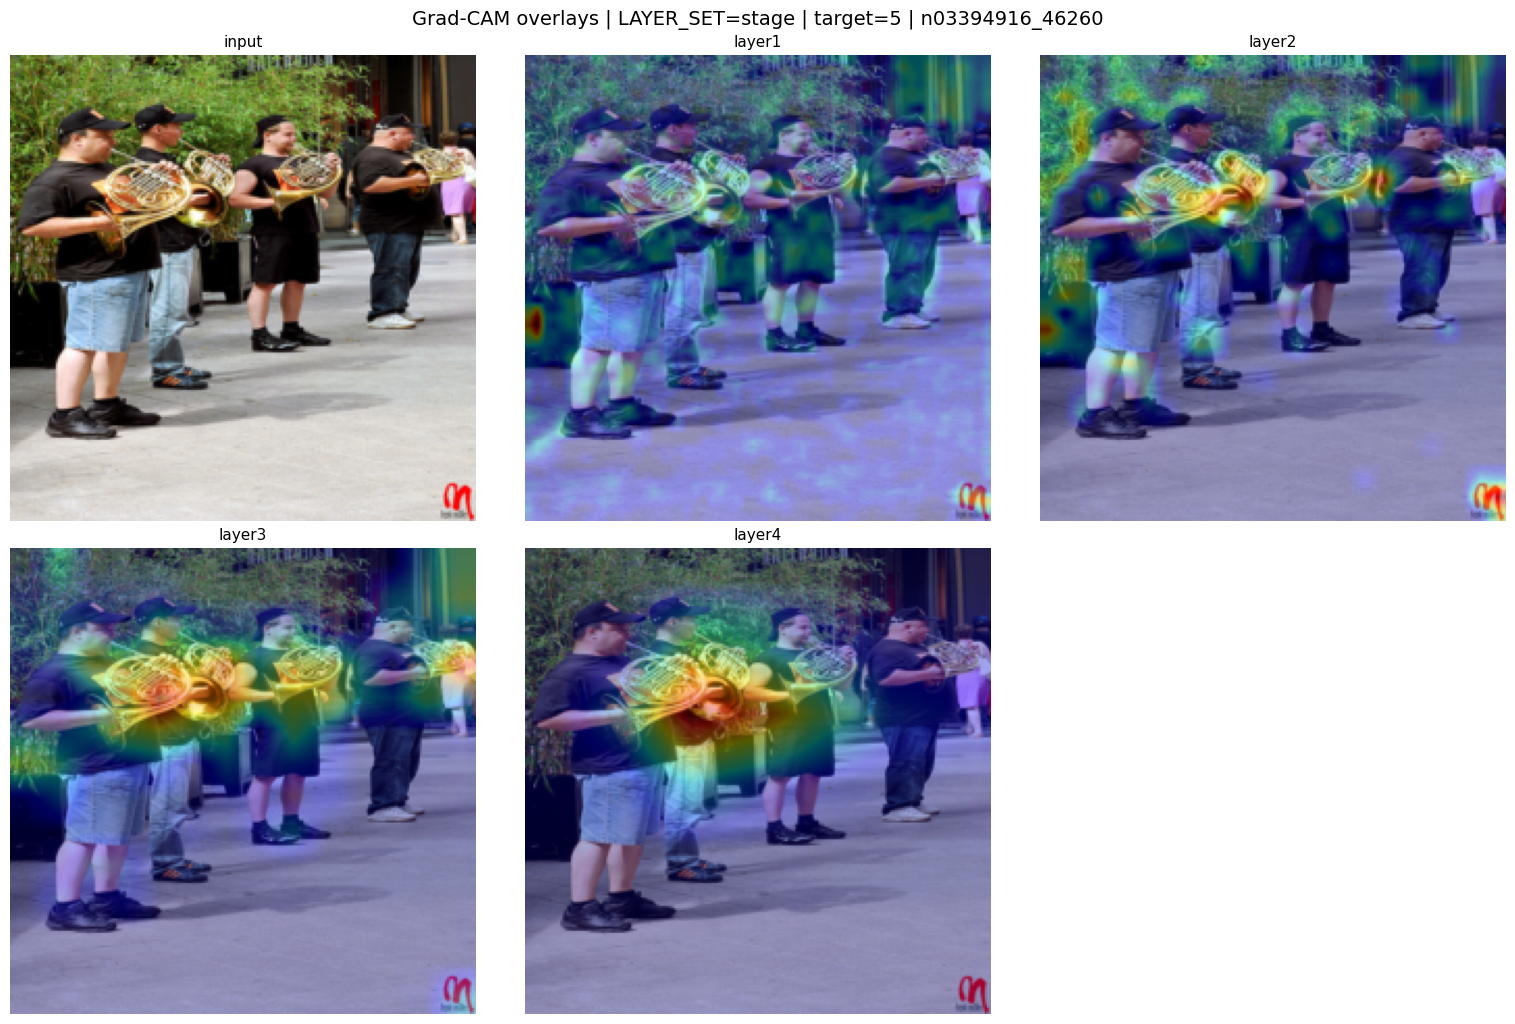

[done] outputs in: figs/gradcam_layers/n03394916_46260
[grid]  figs/gradcam_layers/n03394916_46260/grid_stage_with_input.png


In [20]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.models import resnet50

# ============================
# CONFIG (edit these)
# ============================
CKPT_PATH = "imagenette2_runs/resnet50_imagenette2_best.pt"
VAL_ROOT  = "../../datasets/imagenette2/val"

WNIDS = [
    "n01440764","n02102040","n02979186","n03000684","n03028079",
    "n03394916","n03417042","n03425413","n03445777","n03888257"
]
NUM_CLASSES = len(WNIDS)

# Pick image
IMAGE_INDEX = 2222
IMAGE_FILENAME = None  # e.g. "n01440764_10822.JPEG" (basename or full path ok)

# Target class for Grad-CAM
# None = use argmax prediction for that image
TARGET_CLASS = None

# Layer choices
# "stage" | "last_block" | "last_two"
LAYER_SET = "stage"

OUTDIR = "figs/gradcam_layers"
os.makedirs(OUTDIR, exist_ok=True)

GRID_COLS = 3
OVERLAY_ALPHA = 0.35
APPLY_CAM_GAMMA = True
CAM_GAMMA = 0.8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(True)

# ============================
# MODEL (ResNet50 for 10 classes)
# ============================
model = resnet50(weights=None, num_classes=NUM_CLASSES)

# --- Load checkpoint robustly
ckpt = torch.load(CKPT_PATH, map_location="cpu")
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    sd = ckpt["state_dict"]
elif isinstance(ckpt, dict) and "model" in ckpt:
    sd = ckpt["model"]
elif isinstance(ckpt, dict):
    sd = ckpt
else:
    raise ValueError("Checkpoint format not recognized.")

# strip "module." and "model." if present
sd2 = {}
for k, v in sd.items():
    kk = k
    if kk.startswith("module."):
        kk = kk[len("module."):]
    if kk.startswith("model."):
        kk = kk[len("model."):]
    sd2[kk] = v

missing, unexpected = model.load_state_dict(sd2, strict=False)
print("[ckpt] missing:", len(missing), "unexpected:", len(unexpected))
if missing:
    print("  missing sample:", missing[:10])
if unexpected:
    print("  unexpected sample:", unexpected[:10])

model.eval().to(device)

# ============================
# DATASET INDEXING
# ============================
def list_val_images(val_root, wnids):
    items = []
    for wnid in wnids:
        d = os.path.join(val_root, wnid)
        if not os.path.isdir(d):
            continue
        for p in glob.glob(os.path.join(d, "*.JPEG")):
            items.append((wnid, p))
    # deterministic ordering
    items.sort(key=lambda t: (t[0], os.path.basename(t[1])))
    return items

items = list_val_images(VAL_ROOT, WNIDS)
if not items:
    raise FileNotFoundError(f"No images found under {VAL_ROOT} for provided WNIDS.")

def find_by_filename(items, filename):
    fn = os.path.basename(filename)
    for wnid, path in items:
        if os.path.basename(path) == fn:
            return (wnid, path)
    return None

if IMAGE_FILENAME is not None:
    it = find_by_filename(items, IMAGE_FILENAME)
    if it is None:
        raise FileNotFoundError(f"Could not find filename in val set: {IMAGE_FILENAME}")
    wnid, img_path = it
else:
    idx = int(IMAGE_INDEX)
    if idx < 0 or idx >= len(items):
        raise IndexError(f"IMAGE_INDEX out of range: {idx} (0..{len(items)-1})")
    wnid, img_path = items[idx]

print("[image]", wnid, os.path.basename(img_path))

# ============================
# PREPROCESS (ImageNet-style)
# ============================
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def load_and_preprocess(path, size=224):
    img = Image.open(path).convert("RGB")
    img_resized = img.resize((size, size), resample=Image.BILINEAR)
    x = np.asarray(img_resized).astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    x = np.transpose(x, (2, 0, 1))  # CHW
    x = torch.tensor(x).unsqueeze(0)  # 1x3xHxW
    return img, img_resized, x

img_pil, img_224_pil, x = load_and_preprocess(img_path, size=224)
x = x.to(device)
img_rgb = np.asarray(img_224_pil).astype(np.float32) / 255.0  # HxWx3

# ============================
# LAYER SETS (GOOD DEFAULTS)
# ============================
def layers_stage_outputs(model):
    return [("layer1", model.layer1), ("layer2", model.layer2), ("layer3", model.layer3), ("layer4", model.layer4)]

def layers_last_block_outputs(model):
    return [("layer1[-1]", model.layer1[-1]), ("layer2[-1]", model.layer2[-1]), ("layer3[-1]", model.layer3[-1]), ("layer4[-1]", model.layer4[-1])]

def layers_last_two_blocks(model):
    return [("layer3[-1]", model.layer3[-1]), ("layer4[-1]", model.layer4[-1])]

if LAYER_SET == "stage":
    layers = layers_stage_outputs(model)
elif LAYER_SET == "last_block":
    layers = layers_last_block_outputs(model)
elif LAYER_SET == "last_two":
    layers = layers_last_two_blocks(model)
else:
    raise ValueError(f"Unknown LAYER_SET: {LAYER_SET}")

print(f"[layers] set={LAYER_SET} count={len(layers)}")
for name, _ in layers:
    print("  -", name)

# ============================
# GRAD-CAM (safe: forward hook + torch.autograd.grad; no backward hooks)
# ============================
class GradCAMForward:
    def __init__(self, module: nn.Module):
        self.module = module
        self.activations = None
        self.h = None

    def _fwd_hook(self, module, inp, out):
        self.activations = out

    def install(self):
        self.h = self.module.register_forward_hook(self._fwd_hook)

    def remove(self):
        if self.h is not None:
            self.h.remove()
            self.h = None

def compute_gradcam_for_layer(model, x, target_class, hook: GradCAMForward):
    """
    Returns:
      cam (H,W) at layer resolution in [0,1] (cpu np)
      cam_up (224,224) in [0,1] (cpu np)
      logits_cpu (1,K) tensor on cpu
      cls (int) class used for backprop
    """
    model.zero_grad(set_to_none=True)
    hook.activations = None

    logits = model(x)  # (1,K)
    if target_class is None:
        cls = int(torch.argmax(logits, dim=1).item())
    else:
        cls = int(target_class)

    A = hook.activations
    if A is None:
        raise RuntimeError("Hook did not capture activations for this layer selection.")

    score = logits[0, cls]
    # grads wrt activations
    G = torch.autograd.grad(score, A, retain_graph=True, create_graph=False)[0]

    w = G.mean(dim=(2, 3), keepdim=True)          # (1,C,1,1)
    cam = (w * A).sum(dim=1, keepdim=True)        # (1,1,h,w)
    cam = F.relu(cam)[0, 0]                       # (h,w)

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam_up = F.interpolate(cam[None, None], size=(224, 224), mode="bilinear", align_corners=False)[0, 0]
    cam_up = cam_up - cam_up.min()
    cam_up = cam_up / (cam_up.max() + 1e-8)

    return cam.detach().cpu().numpy(), cam_up.detach().cpu().numpy(), logits.detach().cpu(), cls

def overlay_cam_on_rgb(rgb, cam01, alpha=0.35):
    cmap = plt.get_cmap("jet")  # keep JET
    heat = cmap(cam01)[..., :3]
    out = (1 - alpha) * rgb + alpha * heat
    return np.clip(out, 0.0, 1.0)

# ============================
# RUN
# ============================
cams_up = []
used_cls = None
logits_cpu = None

hooks = []
try:
    for name, module in layers:
        hk = GradCAMForward(module)
        hk.install()
        hooks.append((name, hk))

    for name, hk in hooks:
        cam, cam_up, logits_cpu, cls = compute_gradcam_for_layer(model, x, TARGET_CLASS, hk)
        if used_cls is None:
            used_cls = cls
        cams_up.append((name, cam_up))
finally:
    for _, hk in hooks:
        hk.remove()

probs = torch.softmax(logits_cpu, dim=1)[0]
top5 = torch.topk(probs, k=min(5, probs.numel()))
print("[target] class =", used_cls, "| wnid =", WNIDS[used_cls] if used_cls < len(WNIDS) else "??")
print("[top5 probs]")
for p, idx in zip(top5.values.tolist(), top5.indices.tolist()):
    wn = WNIDS[idx] if idx < len(WNIDS) else "??"
    print(f"  class {idx:2d} ({wn}): {p:.4f}")

# ============================
# SAVE + DISPLAY
# ============================
stem = os.path.splitext(os.path.basename(img_path))[0]
img_outdir = os.path.join(OUTDIR, stem)
os.makedirs(img_outdir, exist_ok=True)

# Save base image
plt.figure(figsize=(4.5, 4.5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"{stem} (wnid={wnid})", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(img_outdir, "input.png"), dpi=180, bbox_inches="tight")
plt.close()

# Per-layer overlay
for name, cam_up in cams_up:
    cam_vis = cam_up.copy()
    if APPLY_CAM_GAMMA:
        cam_vis = np.power(cam_vis, CAM_GAMMA)
        cam_vis = (cam_vis - cam_vis.min()) / (cam_vis.max() + 1e-8)

    over = overlay_cam_on_rgb(img_rgb, cam_vis, alpha=OVERLAY_ALPHA)

    plt.figure(figsize=(5.0, 5.0))
    plt.imshow(over)
    plt.axis("off")
    plt.title(f"{name} | target={used_cls}", fontsize=10)
    plt.tight_layout()
    safe = name.replace("/", "_").replace("[", "_").replace("]", "_")
    plt.savefig(os.path.join(img_outdir, f"gradcam_{safe}.png"), dpi=180, bbox_inches="tight")
    plt.close()

# --- Grid (now includes ORIGINAL image as the first tile) ---
# cams_up is list of (name, cam_up) and img_rgb is HxWx3 in [0,1]
tiles = [("input", None)] + cams_up  # first tile is the original

n = len(tiles)
cols = int(GRID_COLS)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(5.2*cols, 5.2*rows))

for i, (name, cam_up) in enumerate(tiles):
    ax = plt.subplot(rows, cols, i + 1)

    if name == "input":
        ax.imshow(img_rgb)
        ax.set_title("input", fontsize=11)
    else:
        cam_vis = cam_up.copy()
        if APPLY_CAM_GAMMA:
            cam_vis = np.power(cam_vis, CAM_GAMMA)
            cam_vis = (cam_vis - cam_vis.min()) / (cam_vis.max() + 1e-8)

        over = overlay_cam_on_rgb(img_rgb, cam_vis, alpha=OVERLAY_ALPHA)
        ax.imshow(over)
        ax.set_title(name, fontsize=11)

    ax.axis("off")

plt.suptitle(f"Grad-CAM overlays | LAYER_SET={LAYER_SET} | target={used_cls} | {stem}", fontsize=14, y=0.98)
plt.tight_layout()
grid_path = os.path.join(img_outdir, f"grid_{LAYER_SET}_with_input.png")
plt.savefig(grid_path, dpi=180, bbox_inches="tight")
plt.show()

print("[done] outputs in:", img_outdir)
print("[grid] ", grid_path)
